<a href="https://colab.research.google.com/github/shifanamattil/churn-prediction/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 1. Import Libraries
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

In [ ]:
# =========================================================
# 2. Load Datasets
# =========================================================
customer_df = pd.read_csv("customer_data (1).csv")
internet_df = pd.read_csv("internet_data (1).csv")
churn_df = pd.read_csv("churn_data (1).csv")


In [ ]:
# =========================================================
# 3. Merge Datasets
# =========================================================
df = customer_df.merge(internet_df, on="customerID", how="inner")
df = df.merge(churn_df, on="customerID", how="inner")

# Drop customerID
df.drop(columns=["customerID"], inplace=True)


In [ ]:
# =========================================================
# 4. Target Variable
# =========================================================
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


In [ ]:
# =========================================================
# 5. Handle TotalCharges Issue
# =========================================================
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)


In [ ]:
# =========================================================
# 6. Encode Categorical Variables
# =========================================================
df = pd.get_dummies(df, drop_first=True)


In [ ]:
# =========================================================
# 7. Split Features and Target
# =========================================================
X = df.drop("Churn", axis=1)
y = df["Churn"]

feature_names = X.columns



In [ ]:
# =========================================================
# 8. Train Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# =========================================================
# 9. Handle Class Imbalance with SMOTE
# =========================================================
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)



In [ ]:
# =========================================================
# 10. Decision Tree Model
# =========================================================
dt_model = DecisionTreeClassifier(random_state=42)


# =========================================================
# 11. Hyperparameter Grid
# =========================================================
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20]
}


In [ ]:
# =========================================================
# 12. GridSearchCV
# =========================================================
grid = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

best_model = grid.best_estimator_


In [ ]:
# =========================================================
# 13. Predictions
# =========================================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]



In [ ]:
# =========================================================
# 14. Evaluation Metrics
# =========================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n================ MODEL PERFORMANCE ================\n")

print("Best Parameters Found:")
print(grid.best_params_)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")



================ MODEL PERFORMANCE ================

Best Parameters Found:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 20}

Accuracy:  0.7495
Precision: 0.5226
Recall:    0.6497
F1 Score:  0.5793
MCC:       0.4087
ROC-AUC:   0.8102


In [ ]:
# =========================================================
# 15. Sensitivity & Specificity
# =========================================================
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\n================ ADDITIONAL METRICS ================\n")

print(f"Sensitivity (TPR): {sensitivity*100:.2f}%")
print(f"Specificity (TNR): {specificity*100:.2f}%")



================ ADDITIONAL METRICS ================

Sensitivity (TPR): 64.97%
Specificity (TNR): 78.55%


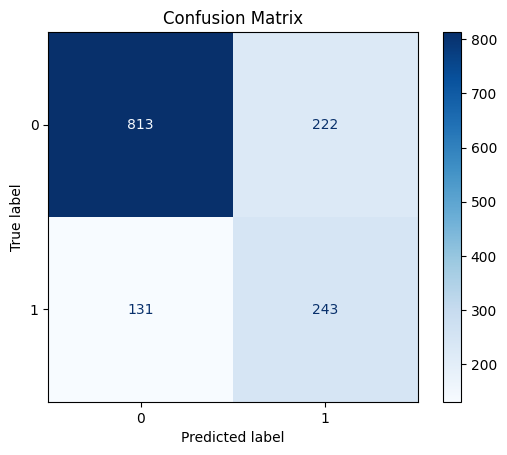

In [ ]:
# =========================================================
# 16. Confusion Matrix Visualization
# =========================================================
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()



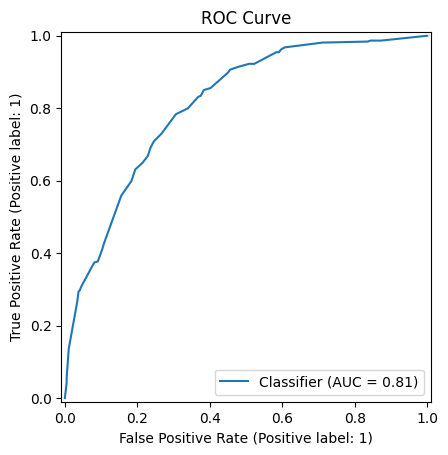

In [ ]:
# =========================================================
# 17. ROC Curve
# =========================================================
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()


In [ ]:
# =========================================================
# 18. Feature Importance
# =========================================================
importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance_df.head(10)

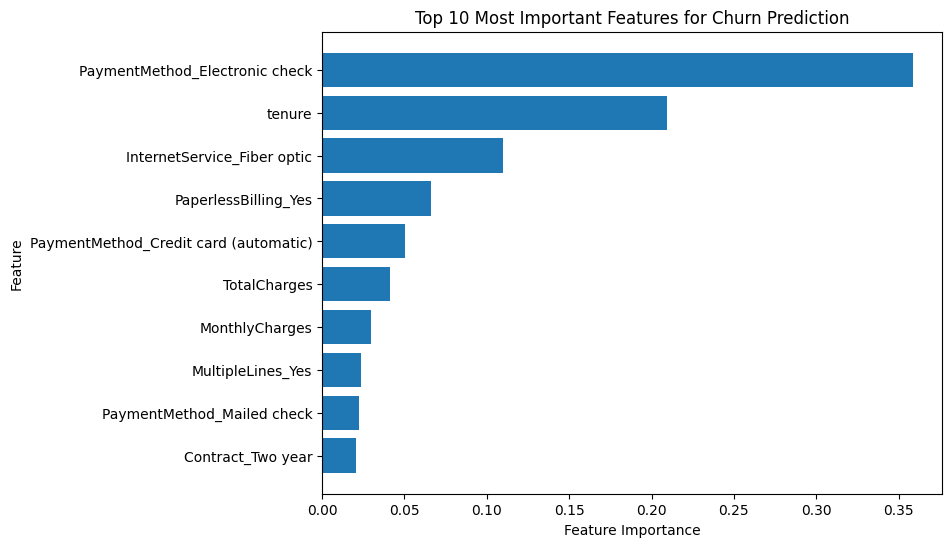

In [ ]:
# =========================================================
# 19. Plot Feature Importance
# =========================================================
plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features for Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()